In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import pandas as pd
import scipy as sp
import os

In [2]:
os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')  # shows current working directory
os.makedirs(r"figures/line01/jacobian_p5_DD", exist_ok=True)

filename = r'data\line01\og_fromtomsnotes_mytopo\project_5\Dipole-Dipole_1-2018-06-11-161704.dat'
data = ert.load(filename)
print(data)

xs = np.array([s.x() for s in data.sensors()])  # an array of all elec x-positions along line
data_min = xs.min(); data_max = xs.max()
print(data_min, data_max)

12/03/26 - 20:10:07 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas
Data: Sensors: 81 data: 1469, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']
0.0 400.0


In [4]:
topo = []

topo_file = r'data\line01\og_fromtomsnotes_mytopo\line01_mytopo.txt'

with open(topo_file) as f: 
    next(f)  # skip header line
    for line in f:
        line = line.strip()
        parts = line.split()  # split using whitespace
        if len(parts) == 2:  # if data has 2 columns it is topo data so add to the list
            topo.append([float(parts[0]), float(parts[1])])

topo = np.array(topo)  # convert to numpy array

topo = topo[np.argsort(topo[:,0])]

x_elec = pg.x(data)  # get x pos of all electrodes
z_elec = np.interp(x_elec, topo[:,0], topo[:,1])  # interpolate topo at each electrode

x_elec = np.array(pg.x(data))  # convert RVector to numpy

# now we ensure topo covers all electrodes at both ends
if topo[0,0] > x_elec.min():  # if topo is to the right of (after) electrode
    topo = np.vstack(([x_elec.min(), topo[0,1]], topo))
if topo[-1,0] < x_elec.max():  # if topo is to the left of (before) electrode
    topo = np.vstack((topo, [x_elec.max(), topo[-1,1]]))

# second interp of topo at electrode positions
z_interp = np.interp(x_elec, topo[:,0], topo[:,1])

# set electrode positions in data
data.setSensorPositions(pg.PosVector(np.c_[x_elec, z_interp]))  # combine into 2D array, convert to gimli pos vector, and update elec pos in ERT dataset

# ensure arrays
x_elec = np.array(pg.x(data))
z_interp = np.array(z_interp)

plt.figure(figsize=(10,4))
plt.plot(x_elec, z_interp, 'r*')
plt.xlabel('Electrode Location [m]')
plt.ylabel('Elevation [m]')
plt.title('Topography')
# plt.show()
plt.close()

In [5]:
def build_electrode_scheme(type, sensors_x, sensors_y):

    elecs = np.c_[sensors_x, sensors_y]   # combine x and z

    # remove the two bad electrodes
    elecs = elecs[2:]

    scheme = ert.createData(elecs=elecs, schemeName=type)

    return scheme

nelecs = 81  # from data file
pos = np.zeros((nelecs, 2))
pos[:, 0] = np.linspace(5, 25, nelecs)
scheme = build_electrode_scheme('gr', x_elec, z_interp)

scheme["k"] = ert.createGeometricFactors(scheme)

12/03/26 - 20:10:54 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 5): C:\Users\sydne\AppData\Roaming\pygimli\Cache\16720028855319410256


12/03/26 - 20:10:54 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 5): C:\Users\sydne\AppData\Roaming\pygimli\Cache\12790587788207374043


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>, None)

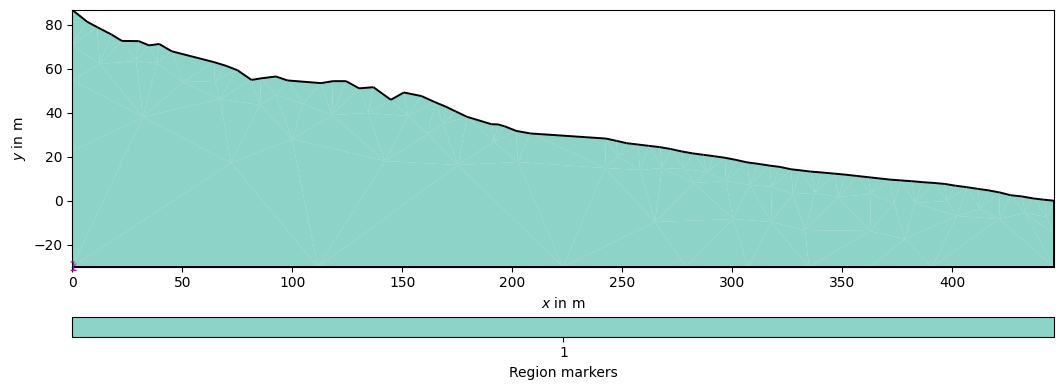

In [7]:
world_bottom = topo[:,1].min() - 30


world_topo = mt.createPolygon(
    [[topo[0,0], world_bottom]] + topo.tolist() + [[topo[-1,0], world_bottom]],
    isClosed=True,marker=1)

top_mean = topo[:,1].mean()

topo_line = mt.createPolygon(
    topo,
    isClosed=False,
    marker=-1
)

# topo nodes are created automatically here
geom = mt.mergePLC([world_topo, topo_line])

fig, ax = plt.subplots(figsize=(16,4))
pg.show(geom, ax=ax)

(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>, None)

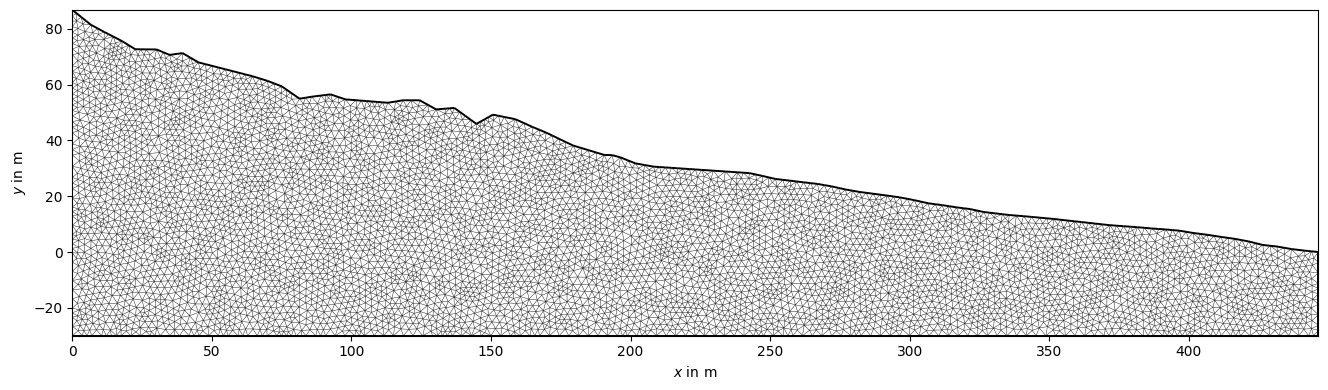

In [14]:
mesh = mt.createMesh(geom, quality=32, area=4, smooth=[1,10])
fig, ax = plt.subplots(figsize=(16,4))
pg.show(mesh, ax=ax, showMesh=True)

> for trouble shooting...

**this is common error**:

mesh cell count: 20450

mesh node count: 10479

Cell for sensor RVector3: (5.0, 86.7172, 0.0): None

sensor outside mesh: RVector3: (5.0, 86.7172, 0.0)

Cell for sensor RVector3: (5.25, 82.72896607105152, 0.0): None

sensor outside mesh: RVector3: (5.25, 82.72896607105152, 0.0)

Cell for sensor RVector3: (5.5, 79.60510881330036, 0.0): <pgcore._pygimli_.Triangle object at 0x00000182585BBDF0> ID: 16781, Marker: 1, Size: 1.8418247009920454 8209 RVector3: (4.679328259648554, 80.14537369749408, 0.0) 8588 RVector3: (5.268856563298982, 77.93652249843612, 0.0) 7790 RVector3: (6.623138830301008, 79.1107517735486, 0.0)

...and we DON'T want it to say *sensor outside mesh*.

In [15]:
print(f'mesh cell count: {mesh.cellCount()}')
print(f'mesh node count: {mesh.nodeCount()}')

for n in mesh.nodes():
    if len(n.cellSet()) == 0:
        print("isolated node:", n.id(), n.pos())

for p in scheme.sensorPositions():
    cell = mesh.findCell(p)
    print(f'Cell for sensor {p}: {cell}')
    if mesh.findCell(p) is None:
        print("sensor outside mesh:", p)

mesh cell count: 11692
mesh node count: 6046
Cell for sensor RVector3: (10.0, 79.60510881330036, 0.0): <pgcore._pygimli_.Triangle object at 0x0000013CBC553DF0>	ID: 11555, Marker: 1, Size: 2.264882578569509
	3 RVector3: (11.405215, 78.8497, 0.0)
	5969 RVector3: (9.040801858, 80.12075, 0.0)
	5971 RVector3: (9.42992442006462, 77.99575784004217, 0.0)

Cell for sensor RVector3: (15.0, 76.99908541985687, 0.0): <pgcore._pygimli_.Triangle object at 0x0000013B496405F0>	ID: 11393, Marker: 1, Size: 3.0118158833297497
	5888 RVector3: (15.426712737265257, 74.8830085846233, 0.0)
	4 RVector3: (17.75790723, 75.5793, 0.0)
	5882 RVector3: (14.581561115, 77.2145, 0.0)

Cell for sensor RVector3: (20.0, 74.19888043162373, 0.0): <pgcore._pygimli_.Triangle object at 0x0000013CBC553DF0>	ID: 11183, Marker: 1, Size: 2.967183044594195
	5780 RVector3: (20.13226021, 74.11745, 0.0)
	4 RVector3: (17.75790723, 75.5793, 0.0)
	5784 RVector3: (17.781043102469305, 73.06569426629918, 0.0)

Cell for sensor RVector3: (25.0,

In [16]:
fop = ert.ERTModelling()  # likely elec nodes are created auto here
fop.setData(scheme)
fop.setMesh(mesh)

model = np.ones(mesh.cellCount())
fop.createJacobian(model)

12/03/26 - 21:00:04 - pyGIMLi - INFO - Found 1 regions.
12/03/26 - 21:00:04 - pyGIMLi - INFO - Creating forward mesh from region infos.
12/03/26 - 21:00:06 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
12/03/26 - 21:00:08 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 23783 Cells: 46768 Boundaries: 35474


In [18]:
def getABMN(scheme, idx):
    """ Get coordinates of four-point cfg with id `idx` from DataContainerERT
    `scheme`."""
    coords = {}
    for elec in "abmn":
        elec_id = int(scheme(elec)[idx])
        elec_pos = scheme.sensorPosition(elec_id)
        coords[elec] = elec_pos.x(), elec_pos.y()
    return coords


def plotABMN(ax, scheme, idx):
    """ Visualize four-point configuration on given axes. """
    coords = getABMN(scheme, idx)
    for elec in coords:
        x, y = coords[elec]
        if elec in "ab":
            color = "red"
        else:
            color = "blue"
        ax.plot(x, y, marker=".", color=color, ms=10)
        ax.annotate(elec.upper(), xy=(x, y), ha="center", fontsize=10, bbox=dict(
            boxstyle="round", fc=(0.8, 0.8, 0.8), ec=color), xytext=(0, 20),
                    textcoords='offset points', arrowprops=dict(
                        arrowstyle="wedge, tail_width=.5", fc=color, ec=color,
                        patchA=None, alpha=0.75))
        ax.plot(coords["a"][0],)

def calc_res_mat(jacobian):
    temp_a = pg.utils.gmat2numpy(jacobian).transpose()
    A = np.matmul(temp_a.transpose(),temp_a)
    B = temp_a.transpose()
    resolution_matrix = sp.linalg.solve(A,B)
    return resolution_matrix

In [ ]:
measure = 6

nplots = len(range(0, len(fop.jacobian()), measure))

fig, ax = plt.subplots(
    nplots, 1,
    sharex=True,
    figsize=(16, 3*nplots)   # width , height per plot
)

for j, i in enumerate(range(0, len(fop.jacobian()), measure)):
    print(f'running measurement {i}...')

    sens = fop.jacobian()[i]

    plotABMN(ax[j], scheme, i)
    resolution_matrix = calc_res_mat(fop.jacobian())


    # normalize by cell size
    normsens = pg.utils.logDropTol(sens/mesh.cellSizes(), 8e-4)

    if i==0:
        norm_sum = np.abs(normsens)
        res_sum = resolution_matrix[i,:]
    else:  # cumulative
        norm_sum = norm_sum+np.abs(normsens)
        res_sum = res_sum+resolution_matrix[i,:]

    # normalize to max
    normsens = np.abs(normsens)
    normsens /= np.max(normsens)

    # from testing
    plotABMN(ax[0], scheme, i)
    pg.show(mesh,normsens, cMap="jet", orientation="vertical",
        label="Normalized Sensitivity", nLevs=3,ax=ax[0])

    # from combining
    # plotABMN(ax[j], scheme, i)
    # resolution_matrix = calc_res_mat(fop.jacobian())

    pg.show(mesh, normsens,
            cMap="jet", ax=ax[j], orientation="vertical", label="Normalized\nsensitivity", nLevs=3,
            cMin=-1, cMax=1)
    ax[j].set_title(f"Measurement {i}")

plt.tight_layout()

running measurement 0...


C:\Users\sydne\AppData\Local\Temp\ipykernel_53588\2806309226.py:33: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.888634508101961e-22.
  resolution_matrix = sp.linalg.solve(A,B)


running measurement 6...
running measurement 12...
running measurement 18...
running measurement 24...
running measurement 30...
running measurement 36...
running measurement 42...
running measurement 48...
running measurement 54...
running measurement 60...
running measurement 66...
running measurement 72...
running measurement 78...
running measurement 84...
running measurement 90...
running measurement 96...
running measurement 102...
running measurement 108...
running measurement 114...
running measurement 120...
running measurement 126...
running measurement 132...
running measurement 138...
running measurement 144...
running measurement 150...
running measurement 156...
running measurement 162...
running measurement 168...


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x13cc910e390>)

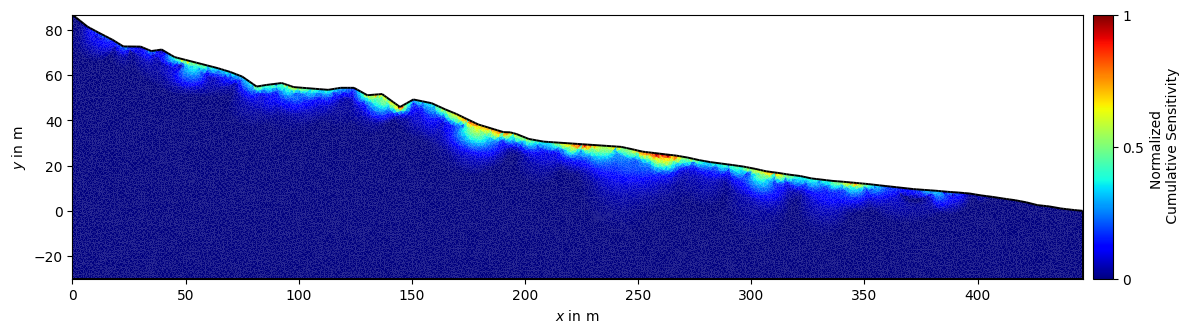

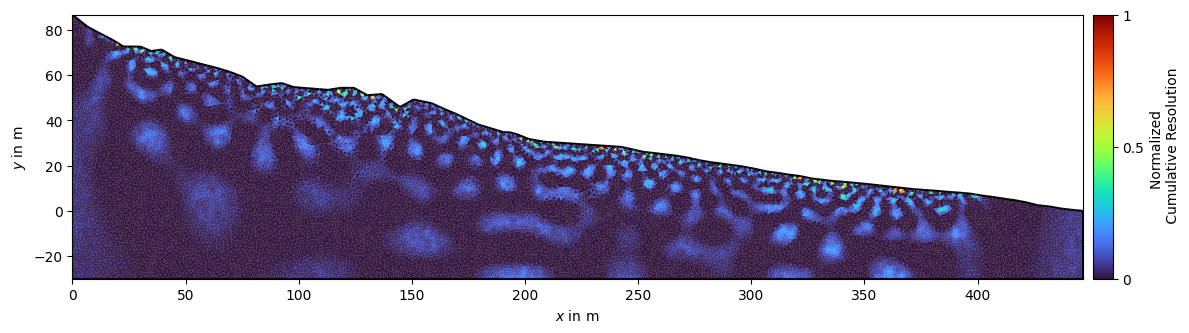

In [13]:
norm_sum /= np.max(norm_sum)
sens_sum = norm_sum

fig, ax = plt.subplots(figsize=(12, 4))

pg.show(mesh, sens_sum, cMap="jet", orientation="vertical",
        label="Normalized \n Cumulative Sensitivity", nLevs=3, cMin=0, cMax=1, ax=ax)

#####

res_sum /= np.max(res_sum)

fig, ax = plt.subplots(figsize=(12, 4))

pg.show(mesh, res_sum, cMap="turbo", orientation="vertical",
        label="Normalized \n Cumulative Resolution", nLevs=3,cMin=0,cMax=1, ax=ax)
